# 🌡️ Temperature Forecasting — LSTM Model
### Weather Forecasting System | Azamgarh ERA5 Dataset
---
**Objective:** Forecast temperature for the next **N hours** (default: 5) using past hourly ERA5 data.  
**Architecture:** LSTM (Long Short-Term Memory) — captures temporal patterns in time series.  
**Input:** Last 24 hours of weather readings → **Output:** Next N hours of temperature.

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & Imports |
| 2 | Data Loading & Inspection |
| 3 | EDA — Time Series Analysis |
| 4 | Preprocessing & Scaling |
| 5 | Sequence Generation (Sliding Window) |
| 6 | Model Architecture |
| 7 | Training with Callbacks |
| 8 | Evaluation & Visualization |
| 9 | Multi-Step Forecasting |
| 10 | Save Model & Artifacts |
| 11 | Inference Function |


## 1. Environment Setup & Imports

In [29]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, RepeatVector, TimeDistributed,
    Reshape
)
from tensorflow.keras.layers import Lambda

import tensorflow as tf
from tensorflow.keras.layers import Lambda
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot style ──
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

# ── Paths ──
DATA_PATH  = "../data/processed/azamgarh_weather_final.csv"
MODEL_DIR  = "../models/lstm1"
SCALER_DIR = "../models/scalers1"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── Key hyperparameters (change these freely) ──
LOOKBACK    = 24    # hours of past data to look at
FORECAST_N  = 5     # hours to predict into future (change to any N)
BATCH_SIZE  = 32
EPOCHS      = 100   # early stopping will kick in before this
TARGET_COL  = "temperature"

print(f"✅  TensorFlow version : {tf.__version__}")
print(f"    Lookback window    : {LOOKBACK} hours")
print(f"    Forecast horizon   : {FORECAST_N} hours")
print(f"    Target column      : {TARGET_COL}")


✅  TensorFlow version : 2.21.0
    Lookback window    : 24 hours
    Forecast horizon   : 5 hours
    Target column      : temperature


## 2. Data Loading & Inspection

In [23]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing    :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()


Shape      : (8736, 18)
Date range : 2025-01-02 05:30:00 → 2026-01-01 04:30:00
Missing    :
Series([], dtype: int64)


,valid_time,temperature,surface_pressure,total_cloud_cover,low_cloud_cover,medium_cloud_cover,high_cloud_cover,precipitation,humidity,wind_speed,hour,day,month,day_of_week,temp_lag_1,temp_lag_24,temp_rolling_6,rain_tomorrow
0,2025-01-02 05:30:00,10.2440,1007.98,0.000000,0.000000,0.0,0.000000,0.0,91.28,1.9575,5,2,1,3,9.7542,12.3051,9.9570,0
1,2025-01-02 06:30:00,10.0340,1008.84,0.000000,0.000000,0.0,0.000000,0.0,91.55,1.7777,6,2,1,3,10.2440,12.6145,9.8854,0
2,2025-01-02 07:30:00,10.1172,1009.33,0.000153,0.000153,0.0,0.000000,0.0,89.64,2.1084,7,2,1,3,10.0340,12.5063,9.9032,0
3,2025-01-02 08:30:00,10.7267,1010.09,0.000000,0.000000,0.0,0.000000,0.0,86.60,1.4957,8,2,1,3,10.1172,12.8654,10.0732,0
4,2025-01-02 09:30:00,11.1407,1010.75,0.000824,0.000488,0.0,0.000336,0.0,85.78,1.5507,9,2,1,3,10.7267,12.2275,10.3361,0


In [24]:
# Basic stats for temperature
print("── Temperature Statistics ──")
print(df[TARGET_COL].describe().round(2))
print(f"\nHourly frequency check (should be ~1h gaps):")
time_diffs = df["valid_time"].diff().dropna()
print(time_diffs.value_counts().head(3))


── Temperature Statistics ──
count    8736.00
mean       25.47
std         7.23
min         7.56
25%        20.36
50%        27.35
75%        30.56
max        42.91
Name: temperature, dtype: float64

Hourly frequency check (should be ~1h gaps):
valid_time
0 days 01:00:00    8735
Name: count, dtype: int64


## 3. EDA — Time Series Analysis

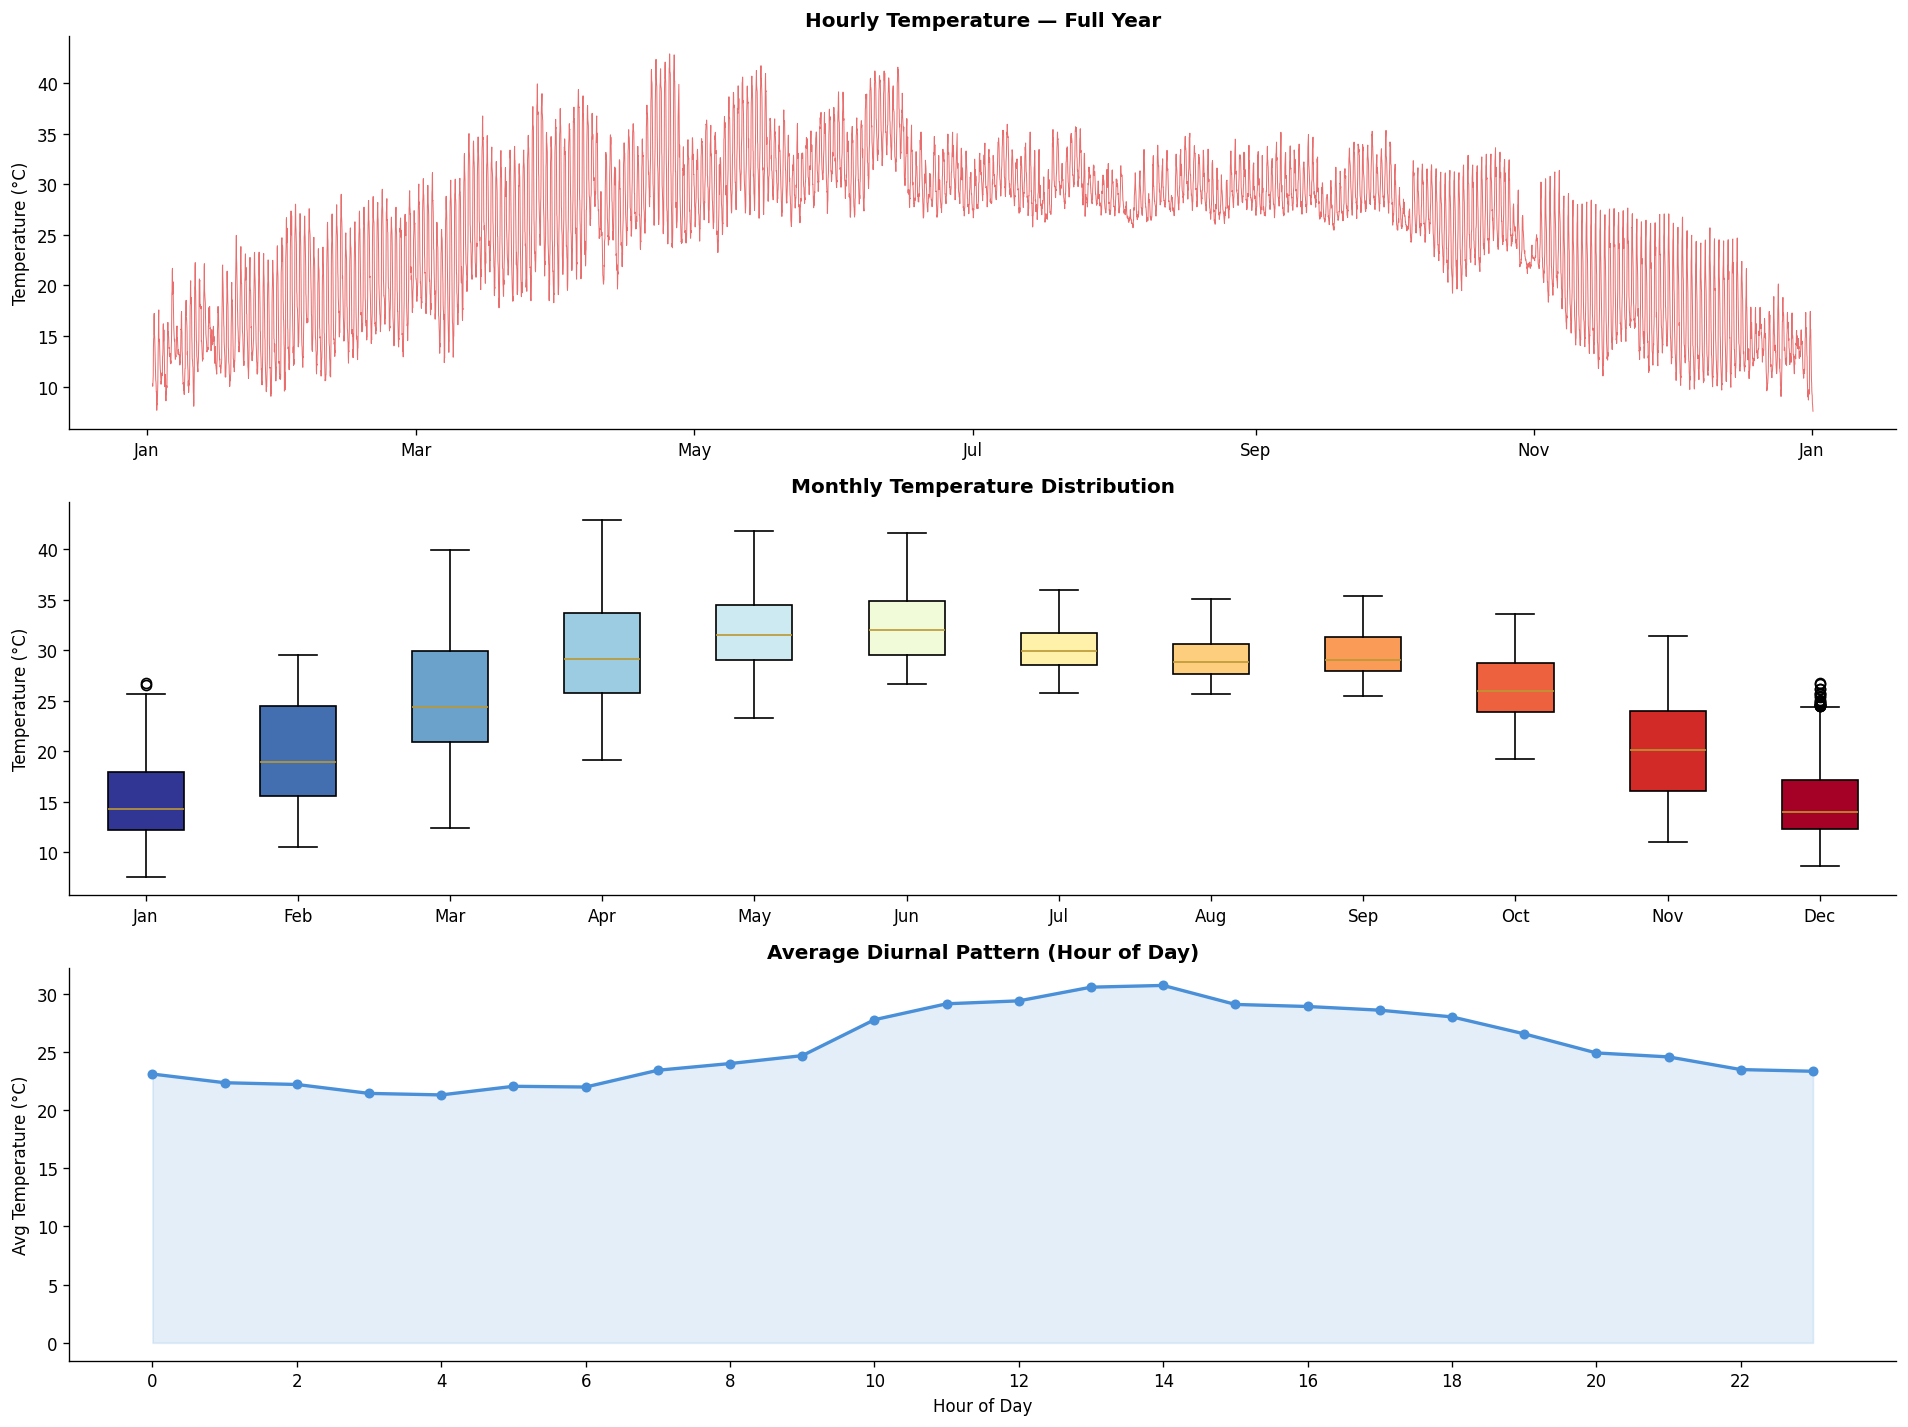

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full year temperature
axes[0].plot(df["valid_time"], df[TARGET_COL], lw=0.6, color="#E85D5D", alpha=0.9)
axes[0].set_title("Hourly Temperature — Full Year", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Monthly boxplot
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_data = [df[df["valid_time"].dt.month == m][TARGET_COL].values for m in range(1,13)]
bp = axes[1].boxplot(monthly_data, patch_artist=True, labels=months)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 12))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("Monthly Temperature Distribution", fontweight="bold")
axes[1].set_ylabel("Temperature (°C)")

# Diurnal pattern (avg temp per hour of day)
df["hour_of_day"] = df["valid_time"].dt.hour
hourly_avg = df.groupby("hour_of_day")[TARGET_COL].mean()
axes[2].plot(hourly_avg.index, hourly_avg.values, "o-", color="#4A90D9", lw=2, ms=5)
axes[2].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color="#4A90D9")
axes[2].set_title("Average Diurnal Pattern (Hour of Day)", fontweight="bold")
axes[2].set_ylabel("Avg Temperature (°C)")
axes[2].set_xlabel("Hour of Day")
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/eda_temperature.png", bbox_inches="tight")
plt.show()


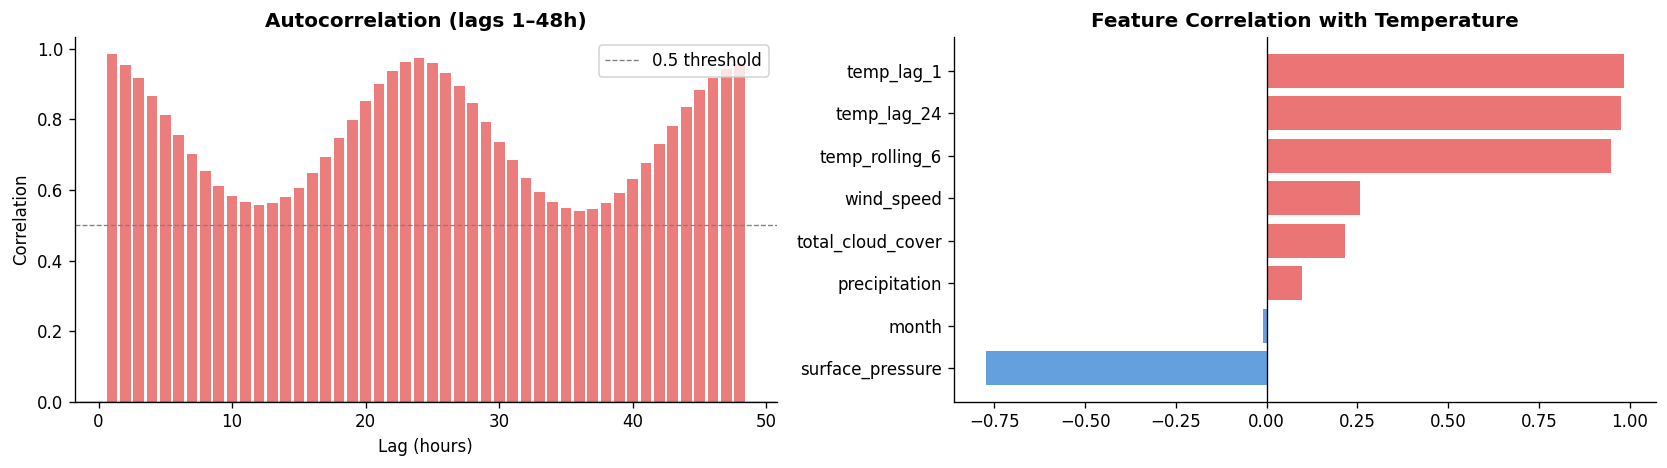


Lag-1 autocorrelation  : 0.9845
Lag-24 autocorrelation : 0.9747
→ High lag-1 & lag-24 confirm LSTM will work well here.


In [26]:
# Autocorrelation — how much does past temp predict future temp?
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Manual lag correlation
lags = range(1, 49)
corr = [df[TARGET_COL].autocorr(lag=l) for l in lags]
axes[0].bar(lags, corr, color=["#E85D5D" if c > 0 else "#4A90D9" for c in corr], alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(0.5, color="gray", lw=0.8, linestyle="--", label="0.5 threshold")
axes[0].set_title("Autocorrelation (lags 1–48h)", fontweight="bold")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Correlation")
axes[0].legend()

# Feature correlation with temperature
feat_corr = df[["temperature","surface_pressure","total_cloud_cover",
                "precipitation","wind_speed","temp_rolling_6",
                "temp_lag_1","temp_lag_24","month"]].corr()[TARGET_COL].drop(TARGET_COL).sort_values()
colors_bar = ["#E85D5D" if v > 0 else "#4A90D9" for v in feat_corr.values]
axes[1].barh(feat_corr.index, feat_corr.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Feature Correlation with Temperature", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/autocorrelation.png", bbox_inches="tight")
plt.show()

print(f"\nLag-1 autocorrelation  : {df[TARGET_COL].autocorr(lag=1):.4f}")
print(f"Lag-24 autocorrelation : {df[TARGET_COL].autocorr(lag=24):.4f}")
print("→ High lag-1 & lag-24 confirm LSTM will work well here.")


## 4. Preprocessing & Scaling

In [27]:
# Select features for LSTM input
FEATURES = [
    "temperature",        # ← target is first column (index 0)
    "surface_pressure",
    "total_cloud_cover",
    "precipitation",
    "humidity",
    "wind_speed",
    "month",
]
N_FEATURES = len(FEATURES)
TARGET_IDX = 0  # temperature is at index 0

print(f"Input features  : {FEATURES}")
print(f"Target index    : {TARGET_IDX} ({FEATURES[TARGET_IDX]})")
print(f"N features      : {N_FEATURES}")

# Drop NaNs
df_model = df[["valid_time"] + FEATURES].dropna().reset_index(drop=True)
print(f"\nRows after dropna: {len(df_model):,}")

# Scale ALL features to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_model[FEATURES].values)

# Save scaler
scaler_path = f"{SCALER_DIR}/lstm_temp_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved → {scaler_path}")


Input features  : ['temperature', 'surface_pressure', 'total_cloud_cover', 'precipitation', 'humidity', 'wind_speed', 'month']
Target index    : 0 (temperature)
N features      : 7

Rows after dropna: 8,736
✅ Scaler saved → ../models/scalers1/lstm_temp_scaler.pkl


## 5. Sequence Generation (Sliding Window)

For each sample: past `LOOKBACK` hours → predict next `FORECAST_N` hours of temperature.

In [28]:
def create_sequences(data, lookback, forecast_n, target_idx=0):
    """
    Sliding window sequence generator.
    
    Args:
        data       : scaled numpy array, shape (n_rows, n_features)
        lookback   : number of past hours as input
        forecast_n : number of future hours to predict
        target_idx : column index of the target variable
    
    Returns:
        X : shape (samples, lookback, n_features)
        y : shape (samples, forecast_n)   ← only temperature
    """
    X, y = [], []
    total = len(data)
    for i in range(total - lookback - forecast_n + 1):
        X.append(data[i : i + lookback])                               # past window
        y.append(data[i + lookback : i + lookback + forecast_n, target_idx])  # future temps
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, LOOKBACK, FORECAST_N, TARGET_IDX)
print(f"X shape : {X.shape}  →  (samples, lookback={LOOKBACK}, features={N_FEATURES})")
print(f"y shape : {y.shape}  →  (samples, forecast_n={FORECAST_N})")

# ── Time-based train/val/test split (no shuffle) ──
n         = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],  y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],    y[val_end:]

print(f"\nSplit:")
print(f"  Train : {len(X_train):>5,} samples  (70%)")
print(f"  Val   : {len(X_val):>5,} samples  (15%)")
print(f"  Test  : {len(X_test):>5,} samples  (15%)")


X shape : (8708, 24, 7)  →  (samples, lookback=24, features=7)
y shape : (8708, 5)  →  (samples, forecast_n=5)

Split:
  Train : 6,095 samples  (70%)
  Val   : 1,306 samples  (15%)
  Test  : 1,307 samples  (15%)


## 6. Model Architecture

Using an **Encoder-Decoder LSTM** — the encoder reads 24h of input, the decoder generates N hours of output. This handles variable-length forecasting cleanly.

In [30]:
def build_lstm_model(lookback, forecast_n, n_features, lstm_units=64):
    """
    Encoder-Decoder LSTM for multi-step temperature forecasting.
    
    Encoder : reads full LOOKBACK sequence
    Decoder : generates FORECAST_N predictions step by step
    """
    inputs = Input(shape=(lookback, n_features), name="encoder_input")

    # ── Encoder ──
    x = Bidirectional(LSTM(lstm_units, return_sequences=True), name="bilstm_1")(inputs)
    x = Dropout(0.2, name="dropout_1")(x)
    x = LSTM(lstm_units // 2, return_sequences=False, name="lstm_encoder")(x)
    x = BatchNormalization(name="bn_encoder")(x)

    # ── Repeat context vector for each forecast step ──
    x = RepeatVector(forecast_n, name="repeat")(x)

    # # ── Decoder ──
    # x = LSTM(lstm_units // 2, return_sequences=True, name="lstm_decoder")(x)
    # x = Dropout(0.2, name="dropout_2")(x)
    # x = BatchNormalization(name="bn_decoder")(x)
    # ── Decoder ──
    x = LSTM(
        lstm_units // 2,
        return_sequences=True,
        name="lstm_decoder"
    )(x)

    x = Dropout(0.2, name="dropout_dec_1")(x)
    x = BatchNormalization(name="bn_decoder")(x)

    outputs = TimeDistributed(
        Dense(1),
        name="td_dense"
    )(x)

    outputs = Reshape(
        (forecast_n,),
        name="reshape_output"
    )(outputs)
    # ── Output: 1 temperature value per forecast step ──
    # outputs = TimeDistributed(Dense(1), name="output")(x)
    # outputs = tf.squeeze(outputs, axis=-1)   # (batch, forecast_n)

    # def squeeze_last_dim(x):
    #     return tf.squeeze(x, axis=-1)

    # def squeeze_output_shape(input_shape):
    #     return (input_shape[0], input_shape[1])

    # outputs = Lambda(
    #     squeeze_last_dim,
    #     output_shape=squeeze_output_shape,
    #     name="squeeze_output"
    # )(outputs)
    model = Model(inputs, outputs, name="LSTM_TempForecaster")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="huber",          # robust to outliers vs MSE
        metrics=["mae"]
    )
    return model

model = build_lstm_model(LOOKBACK, FORECAST_N, N_FEATURES, lstm_units=64)
model.summary()


Model: "LSTM_TempForecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 24, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_encoder (BatchNormalization) │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_decoder (LSTM)             │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dec_1 (Dropout)         │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_decoder (BatchNormalization) │ (None, 5, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_dense (TimeDistributed)      │ (None, 5, 1)           │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_output (Reshape)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,081 (258.13 KB)

 Trainable params: 65,953 (257.63 KB)

 Non-trainable params: 128 (512.00 B)

In [31]:
# Visualize architecture
print("\n── Architecture Summary ──")
print(f"  Input  : ({LOOKBACK} hours, {N_FEATURES} features)")
print(f"  BiLSTM : 64 units → learns forward & backward patterns")
print(f"  LSTM   : 32 units → compresses to context vector")
print(f"  Repeat : context vector repeated {FORECAST_N} times")
print(f"  LSTM   : 32 units → decodes each forecast step")
print(f"  Output : {FORECAST_N} temperature values")
print(f"  Loss   : Huber (robust to temp spikes/outliers)")
print(f"  Params : {model.count_params():,}")



── Architecture Summary ──
  Input  : (24 hours, 7 features)
  BiLSTM : 64 units → learns forward & backward patterns
  LSTM   : 32 units → compresses to context vector
  Repeat : context vector repeated 5 times
  LSTM   : 32 units → decodes each forecast step
  Output : 5 temperature values
  Loss   : Huber (robust to temp spikes/outliers)
  Params : 66,081


## 7. Training with Callbacks

In [32]:
callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{MODEL_DIR}/best_model.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

print(f"Training on {len(X_train):,} samples, validating on {len(X_val):,} ...")
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    verbose         = 1,
)
print(f"\n✅ Training complete. Best epoch: {np.argmin(history.history['val_loss']) + 1}")


Training on 6,095 samples, validating on 1,306 ...
Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.1376 - mae: 0.4003 - val_loss: 0.0098 - val_mae: 0.1187 - learning_rate: 0.0010
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0410 - mae: 0.2157 - val_loss: 0.0051 - val_mae: 0.0849 - learning_rate: 0.0010
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0178 - mae: 0.1445 - val_loss: 0.0018 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0097 - mae: 0.1079 - val_loss: 0.0012 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0061 - mae: 0.0862 - val_loss: 8.8723e-04 - val_mae: 0.0329 - learning_rate: 0.0010
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0042 - mae: 0.0717 - val_loss: 8.5347e-04 - val_mae: 0.0322 - learning_rate: 0.0010
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0033 - mae: 

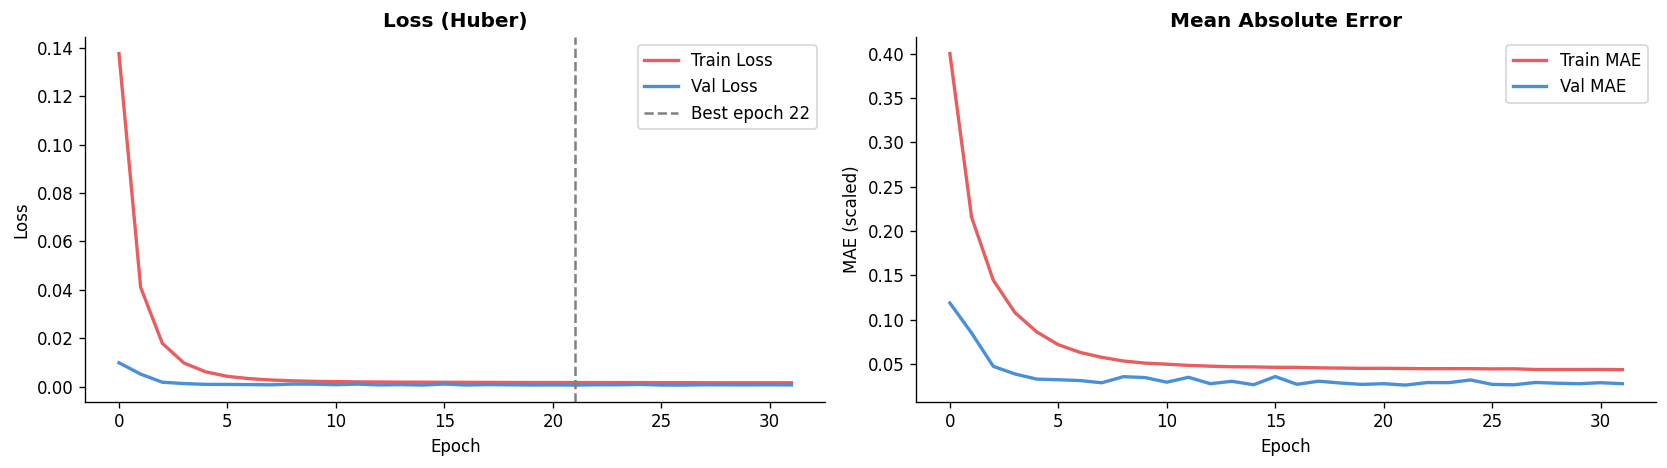

In [33]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Train Loss", color="#E85D5D", lw=2)
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="#4A90D9", lw=2)
best_ep = np.argmin(history.history["val_loss"])
axes[0].axvline(best_ep, color="gray", linestyle="--", label=f"Best epoch {best_ep+1}")
axes[0].set_title("Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE", color="#E85D5D", lw=2)
axes[1].plot(history.history["val_mae"], label="Val MAE",   color="#4A90D9", lw=2)
axes[1].set_title("Mean Absolute Error", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (scaled)")
axes[1].legend()

plt.tight_layout()
# plt.savefig(f"{MODEL_DIR}/training_curves.png", bbox_inches="tight")
plt.show()


## 8. Evaluation & Visualization

In [34]:
def inverse_temp(scaled_vals):
    """Inverse transform only the temperature column back to °C."""
    # Reconstruct a full feature-width array (zeros for other features)
    dummy = np.zeros((len(scaled_vals), N_FEATURES))
    dummy[:, TARGET_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

# Predict on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform — flatten for metrics, keep shape for per-step analysis
y_true_all = np.array([inverse_temp(y_test[i])  for i in range(len(y_test))])
y_pred_all = np.array([inverse_temp(y_pred_scaled[i]) for i in range(len(y_pred_scaled))])

# Overall metrics
mae  = mean_absolute_error(y_true_all.flatten(), y_pred_all.flatten())
rmse = np.sqrt(mean_squared_error(y_true_all.flatten(), y_pred_all.flatten()))
r2   = r2_score(y_true_all.flatten(), y_pred_all.flatten())

print("═" * 45)
print("  TEST SET RESULTS (all forecast steps)")
print("═" * 45)
print(f"  MAE  : {mae:.4f} °C")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  R²   : {r2:.4f}")
print("═" * 45)

# Per-step metrics
print("\n── Per-Step Accuracy ──")
print(f"{'Step':>6} {'Hour+':>6} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 42)
for step in range(FORECAST_N):
    step_mae  = mean_absolute_error(y_true_all[:, step], y_pred_all[:, step])
    step_rmse = np.sqrt(mean_squared_error(y_true_all[:, step], y_pred_all[:, step]))
    step_r2   = r2_score(y_true_all[:, step], y_pred_all[:, step])
    print(f"{step+1:>6} {f'+{step+1}h':>6} {step_mae:>8.4f} {step_rmse:>8.4f} {step_r2:>8.4f}")


═════════════════════════════════════════════
  TEST SET RESULTS (all forecast steps)
═════════════════════════════════════════════
  MAE  : 2.6588 °C
  RMSE : 3.0362 °C
  R²   : 0.5903
═════════════════════════════════════════════

── Per-Step Accuracy ──
  Step  Hour+      MAE     RMSE       R²
──────────────────────────────────────────
     1    +1h   3.4517   3.7467   0.3767
     2    +2h   2.4118   2.7688   0.6588
     3    +3h   2.3350   2.7209   0.6706
     4    +4h   2.4750   2.8415   0.6411
     5    +5h   2.6203   2.9854   0.6045


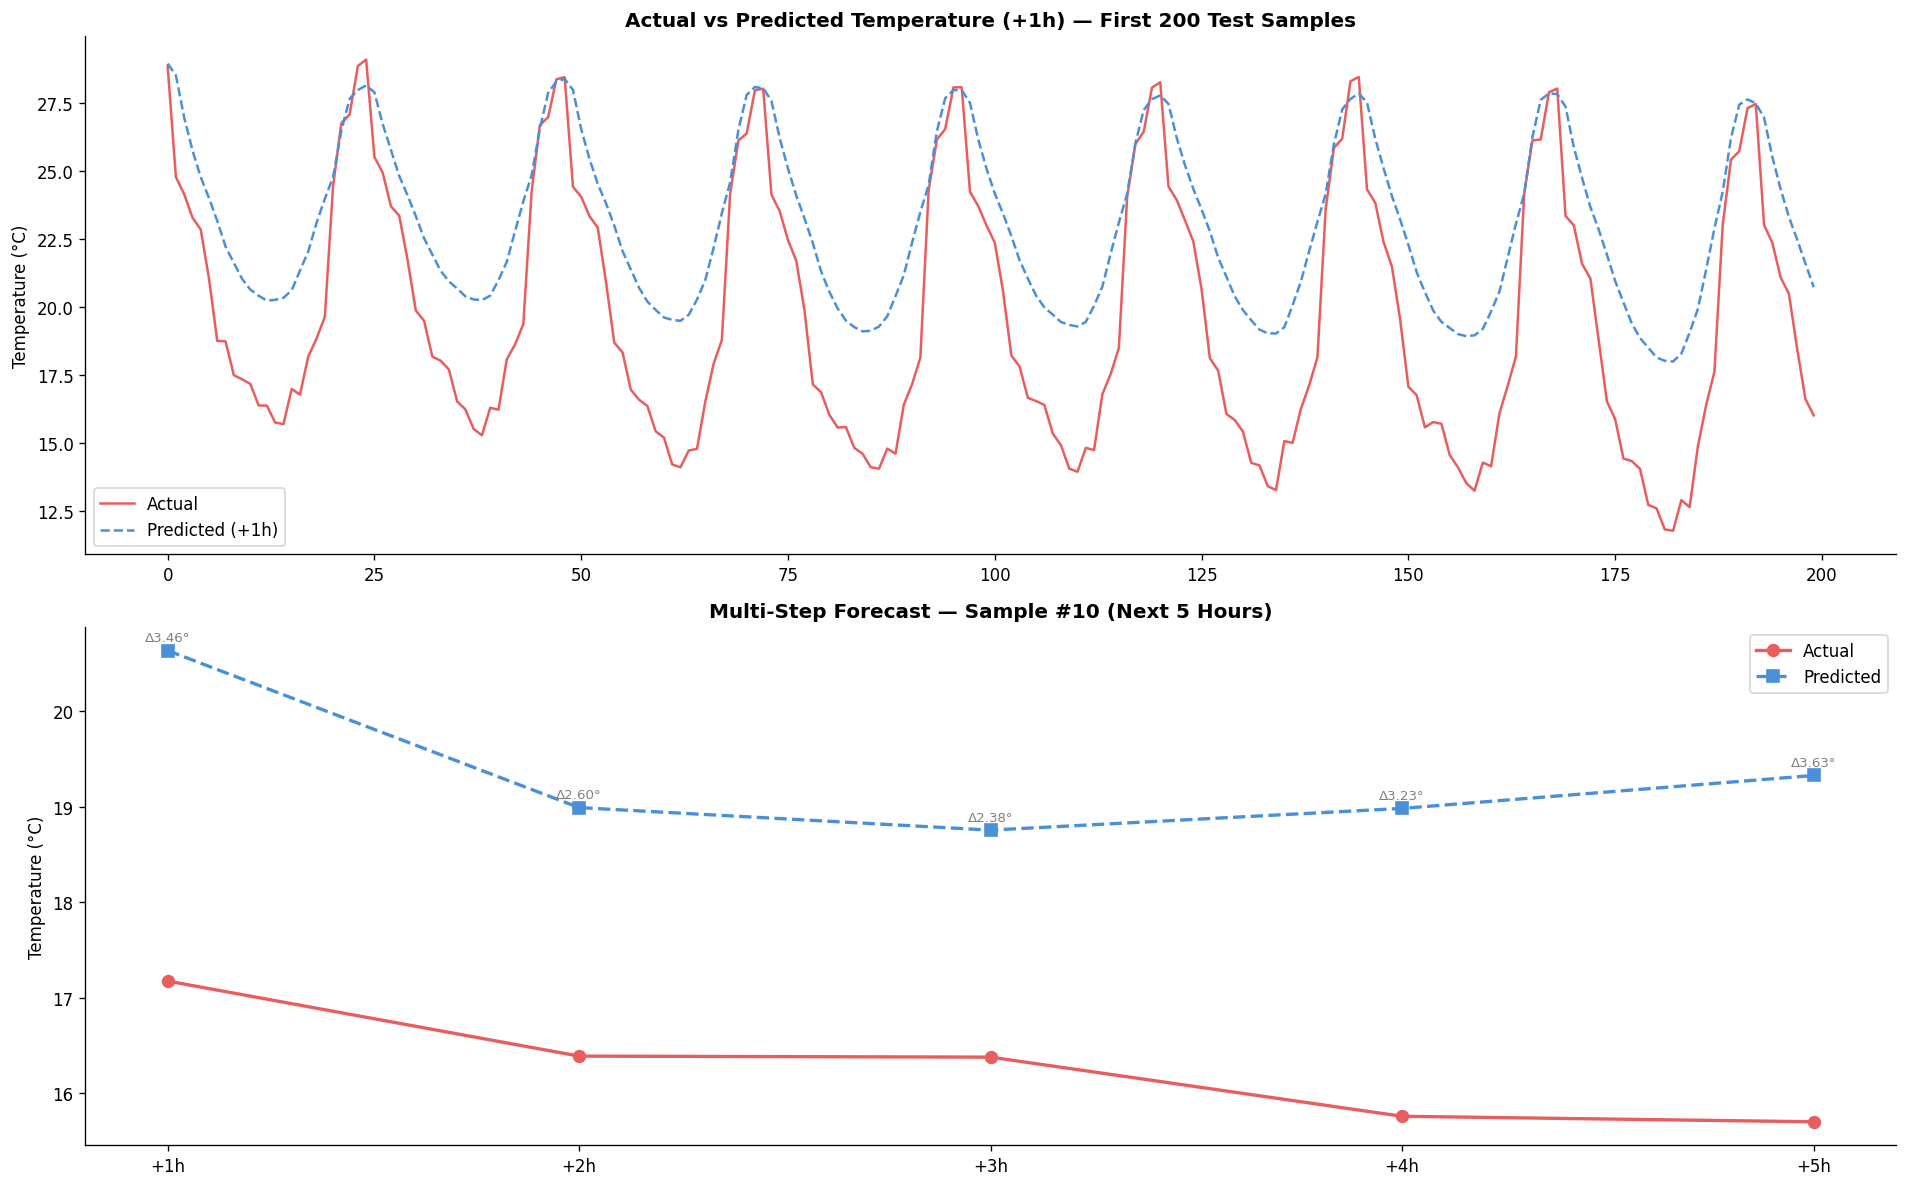

In [13]:
# Visualize predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: first 200 test samples, step+1h prediction
n_show = min(200, len(y_true_all))
axes[0].plot(range(n_show), y_true_all[:n_show, 0], label="Actual",    color="#E85D5D", lw=1.5)
axes[0].plot(range(n_show), y_pred_all[:n_show, 0], label="Predicted (+1h)", color="#4A90D9", lw=1.5, linestyle="--")
axes[0].set_title(f"Actual vs Predicted Temperature (+1h) — First {n_show} Test Samples", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# Plot 2: all N forecast steps for a single sample
sample_idx = 10
actual_sample = y_true_all[sample_idx]
pred_sample   = y_pred_all[sample_idx]
steps = [f"+{i+1}h" for i in range(FORECAST_N)]
axes[1].plot(steps, actual_sample, "o-", label="Actual",    color="#E85D5D", lw=2, ms=7)
axes[1].plot(steps, pred_sample,   "s--", label="Predicted", color="#4A90D9", lw=2, ms=7)
for i, (a, p) in enumerate(zip(actual_sample, pred_sample)):
    axes[1].annotate(f"Δ{abs(a-p):.2f}°", (steps[i], max(a,p)+0.1), ha="center", fontsize=8, color="gray")
axes[1].set_title(f"Multi-Step Forecast — Sample #{sample_idx} (Next {FORECAST_N} Hours)", fontweight="bold")
axes[1].set_ylabel("Temperature (°C)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/predictions.png", bbox_inches="tight")
plt.show()


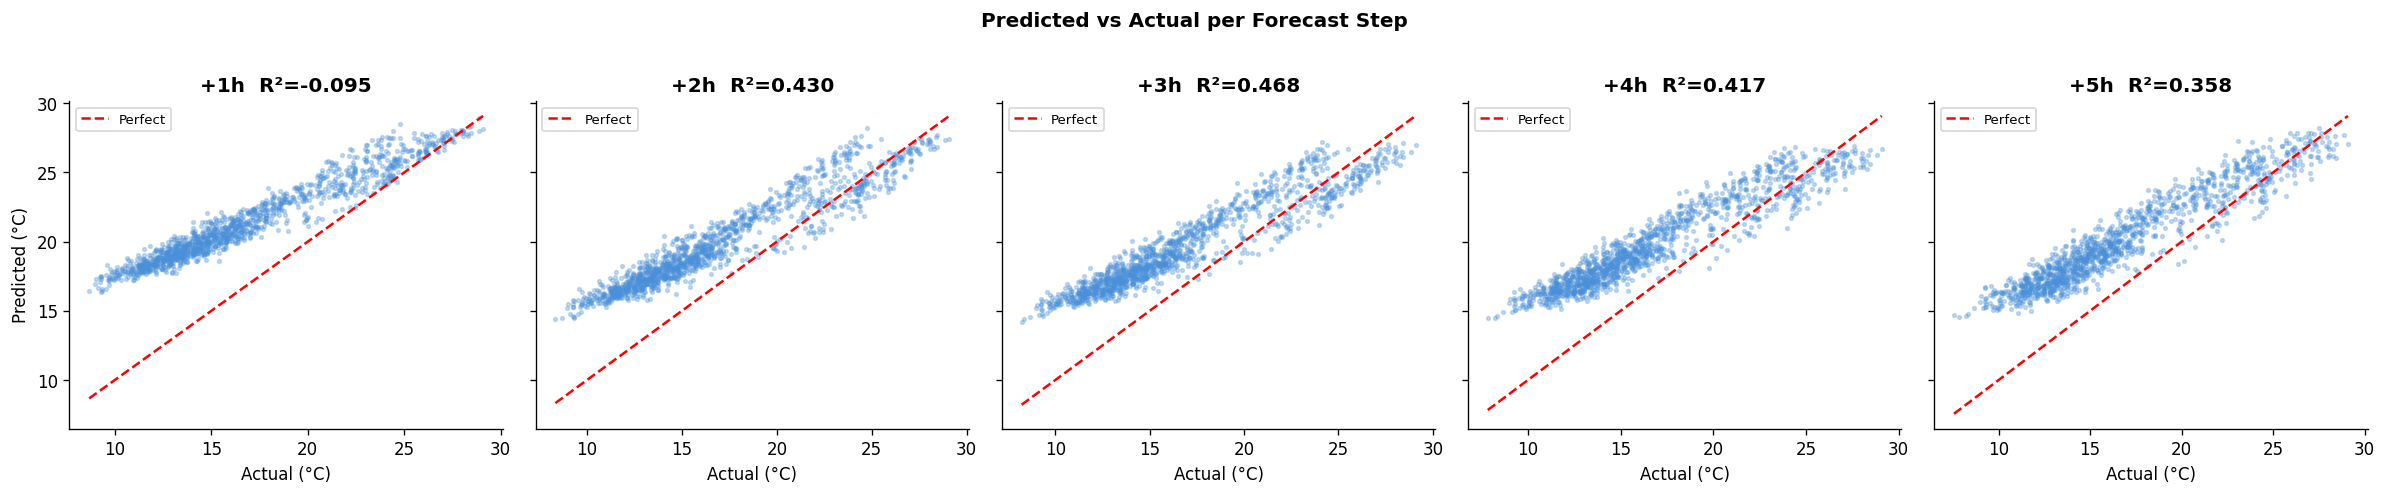

In [14]:
# Scatter: predicted vs actual per step
fig, axes = plt.subplots(1, FORECAST_N, figsize=(4*FORECAST_N, 4), sharey=True)
if FORECAST_N == 1: axes = [axes]

for step, ax in enumerate(axes):
    ax.scatter(y_true_all[:, step], y_pred_all[:, step],
               alpha=0.3, s=5, color="#4A90D9")
    lims = [min(y_true_all[:,step].min(), y_pred_all[:,step].min()),
            max(y_true_all[:,step].max(), y_pred_all[:,step].max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
    step_r2 = r2_score(y_true_all[:, step], y_pred_all[:, step])
    ax.set_title(f"+{step+1}h  R²={step_r2:.3f}", fontweight="bold")
    ax.set_xlabel("Actual (°C)")
    if step == 0: ax.set_ylabel("Predicted (°C)")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual per Forecast Step", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/scatter_per_step.png", bbox_inches="tight")
plt.show()


## 9. Multi-Step Forecasting — Live Demo

Give the model a 24-hour window and get the next N hours forecast.

In [15]:
def forecast_next_n_hours(recent_24h: pd.DataFrame, n_hours: int = FORECAST_N) -> pd.DataFrame:
    """
    Forecast temperature for the next n_hours given last 24h of weather data.
    
    Args:
        recent_24h : DataFrame with columns matching FEATURES, length >= LOOKBACK (24 rows)
        n_hours    : number of hours to forecast (default = FORECAST_N)
    
    Returns:
        DataFrame with columns: hour, predicted_temperature_C, lower_bound, upper_bound
    
    Usage:
        recent = df.tail(24)[FEATURES]
        result = forecast_next_n_hours(recent, n_hours=5)
        print(result)
    """
    assert len(recent_24h) >= LOOKBACK, f"Need at least {LOOKBACK} rows, got {len(recent_24h)}"
    
    # Use last LOOKBACK rows
    window = recent_24h[FEATURES].iloc[-LOOKBACK:].values
    
    # Scale using fitted scaler
    window_scaled = scaler.transform(window)
    X_input = window_scaled.reshape(1, LOOKBACK, N_FEATURES)
    
    # If n_hours != FORECAST_N, rebuild model output — for now use available predictions
    pred_scaled = model.predict(X_input, verbose=0)[0]   # shape: (FORECAST_N,)
    
    # Inverse transform predictions
    dummy = np.zeros((len(pred_scaled), N_FEATURES))
    dummy[:, TARGET_IDX] = pred_scaled
    pred_temps = scaler.inverse_transform(dummy)[:, TARGET_IDX]
    
    # Confidence interval (±1 MAE as simple bound)
    margin = mae
    result = pd.DataFrame({
        "hour"                    : [f"+{i+1}h" for i in range(len(pred_temps))],
        "predicted_temperature_C" : pred_temps.round(2),
        "lower_bound_C"           : (pred_temps - margin).round(2),
        "upper_bound_C"           : (pred_temps + margin).round(2),
    })
    return result


# ── Test on last 24h of dataset ──
recent_window = df_model.tail(LOOKBACK + 5)  # a little extra for safety
forecast_df   = forecast_next_n_hours(recent_window)

print("── Forecast for Next Hours ──")
print(forecast_df.to_string(index=False))


── Forecast for Next Hours ──
hour  predicted_temperature_C  lower_bound_C  upper_bound_C
 +1h                    14.33          10.80          17.86
 +2h                    12.94           9.41          16.47
 +3h                    13.21           9.69          16.74
 +4h                    13.73          10.20          17.26
 +5h                    14.18          10.66          17.71


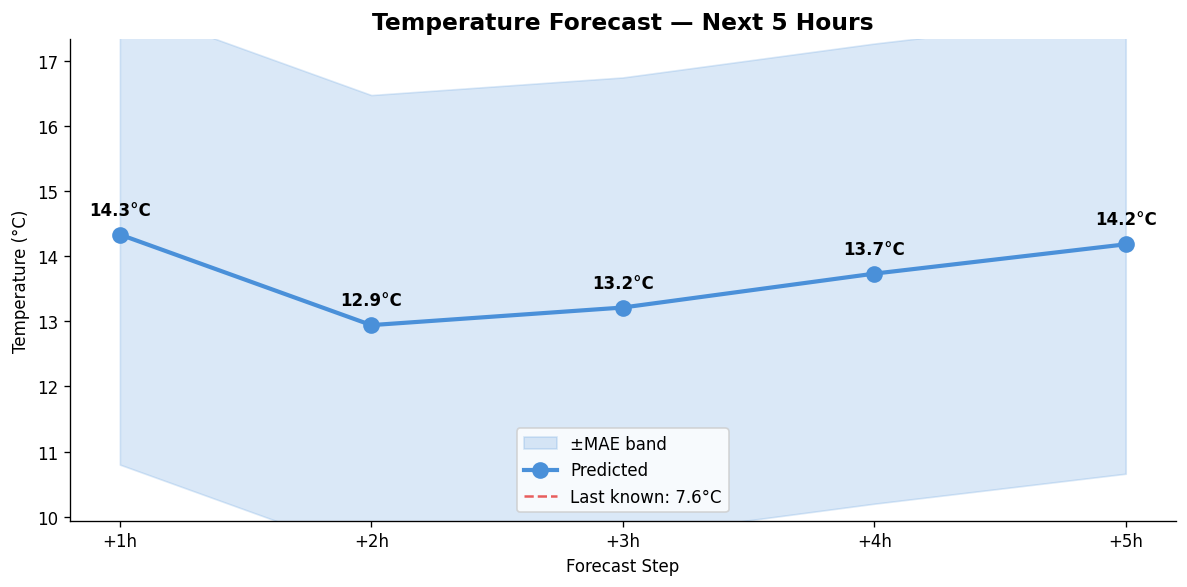

In [16]:
# Plot forecast with confidence band
fig, ax = plt.subplots(figsize=(10, 5))

hours = forecast_df["hour"].values
temps = forecast_df["predicted_temperature_C"].values
lo    = forecast_df["lower_bound_C"].values
hi    = forecast_df["upper_bound_C"].values

ax.fill_between(hours, lo, hi, alpha=0.2, color="#4A90D9", label="±MAE band")
ax.plot(hours, temps, "o-", color="#4A90D9", lw=2.5, ms=9, label="Predicted")

# Annotate each point
for h, t in zip(hours, temps):
    ax.annotate(f"{t:.1f}°C", (h, t), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")

# Show last known actual temp
last_actual = df_model[TARGET_COL].iloc[-1]
ax.axhline(last_actual, color="#E85D5D", linestyle="--", lw=1.5,
           label=f"Last known: {last_actual:.1f}°C")

ax.set_title(f"Temperature Forecast — Next {FORECAST_N} Hours", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Forecast Step")
ax.legend()
ax.set_ylim(temps.min() - 3, temps.max() + 3)

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/forecast_plot.png", bbox_inches="tight")
plt.show()


## 10. Save Model & Artifacts

In [20]:
# Save full Keras model
model_path = f"{MODEL_DIR}/lstm_temp_model.keras"
model.save(model_path)
print(f"✅ Model saved   → {model_path}")

# Save metadata
meta = {
    "model"          : "Encoder-Decoder BiLSTM",
    "target"         : TARGET_COL,
    "features"       : FEATURES,
    "target_idx"     : TARGET_IDX,
    "lookback"       : LOOKBACK,
    "forecast_n"     : FORECAST_N,
    "n_features"     : N_FEATURES,
    "train_samples"  : int(len(X_train)),
    "test_samples"   : int(len(X_test)),
    "metrics": {
        "mae_celsius"  : round(float(mae), 4),
        "rmse_celsius" : round(float(rmse), 4),
        "r2_score"     : round(float(r2), 4),
    },
    "per_step_mae": {
        f"+{s+1}h": round(float(mean_absolute_error(
            y_true_all[:, s], y_pred_all[:, s])), 4)
        for s in range(FORECAST_N)
    },
    "scaler_path": scaler_path,
}

meta_path = f"{MODEL_DIR}/model_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Metadata saved → {meta_path}")
print(f"\n── Saved Files ──")
print(f"   {model_path}")
print(f"   {meta_path}")
print(f"   {scaler_path}")
print(f"\nFinal Metrics:")
for k, v in meta["metrics"].items():
    print(f"  {k:<18}: {v}")


✅ Model saved   → ../models/lstm/lstm_temp_model.keras
✅ Metadata saved → ../models/lstm/model_meta.json

── Saved Files ──
   ../models/lstm/lstm_temp_model.keras
   ../models/lstm/model_meta.json
   ../models/scalers/lstm_temp_scaler.pkl

Final Metrics:
  mae_celsius       : 3.4391
  rmse_celsius      : 3.8349
  r2_score          : 0.3464


## 11. Inference Function
This is what `app/services/predictor.py` will import for temperature forecasting.

In [8]:
# ── Reload model fresh (simulates app startup) ──
# loaded_model  = load_model(f"{MODEL_DIR}/lstm_temp_model.keras")
import tensorflow as tf

def squeeze_last_dim(x):
    return tf.squeeze(x, axis=-1)

def squeeze_output_shape(input_shape):
    return (input_shape[0], input_shape[1])
from keras.models import load_model
from keras.models import load_model

loaded_model = load_model(
    f"{MODEL_DIR}/lstm_temp_model.keras",

    custom_objects={
        "squeeze_last_dim": squeeze_last_dim,
        "squeeze_output_shape": squeeze_output_shape,
    },

    safe_mode=False
)
# model = load_model(
#     f"{MODEL_DIR}/lstm_temp_model.keras",
#     safe_mode=False
# )
scaler_path = f"{SCALER_DIR}/lstm_temp_scaler.pkl"
loaded_scaler = joblib.load(scaler_path)
with open(f"{MODEL_DIR}/model_meta.json") as f:
    loaded_meta = json.load(f)

print("✅ Model & scaler reloaded successfully")
print(f"   Loaded FORECAST_N : {loaded_meta['forecast_n']}")
print(f"   Loaded features   : {loaded_meta['features']}")


✅ Model & scaler reloaded successfully
   Loaded FORECAST_N : 5
   Loaded features   : ['temperature', 'surface_pressure', 'total_cloud_cover', 'precipitation', 'humidity', 'wind_speed', 'month']


In [11]:
import pandas as pd
def predict_temperature(recent_df: pd.DataFrame, n_hours: int = 5) -> dict:
    """
    Predict temperature for next n_hours.
    Import this function into app/services/predictor.py.
    
    Args:
        recent_df : DataFrame with FEATURES columns, minimum 24 rows (hourly)
        n_hours   : override forecast horizon (must be <= FORECAST_N trained with)
    
    Returns:
        dict with forecast list and metadata
    
    Example (in app/services/predictor.py):
        from pipeline.train_lstm import predict_temperature
        recent = fetch_last_24h_from_openmeteo()   # returns DataFrame
        result = predict_temperature(recent, n_hours=5)
        # result["forecast"] → [{"hour": "+1h", "temp": 28.3}, ...]
    """
    _meta     = loaded_meta
    _model    = loaded_model
    _scaler   = loaded_scaler
    _lookback = _meta["lookback"]
    _fn       = _meta["forecast_n"]
    _feats    = _meta["features"]
    _tidx     = _meta["target_idx"]
    _nfeat    = _meta["n_features"]
    
    n = n_hours if n_hours else _fn
    assert n <= _fn, f"n_hours={n} exceeds trained forecast_n={_fn}. Retrain with larger FORECAST_N."
    assert len(recent_df) >= _lookback, f"Need {_lookback} rows, got {len(recent_df)}"
    
    window = recent_df[_feats].iloc[-_lookback:].values
    window_scaled = _scaler.transform(window).reshape(1, _lookback, _nfeat)
    
    pred_scaled = _model.predict(window_scaled, verbose=0)[0][:n]
    dummy = np.zeros((n, _nfeat))
    dummy[:, _tidx] = pred_scaled
    pred_temps = _scaler.inverse_transform(dummy)[:, _tidx]
    
    forecast = [
        {"hour": f"+{i+1}h", "temperature_C": round(float(t), 2)}
        for i, t in enumerate(pred_temps)
    ]
    return {
        "forecast"    : forecast,
        "n_hours"     : n,
        "model"       : _meta["model"],
        "mae_celsius" : _meta["metrics"]["mae_celsius"],
    }


# ── Live demo ──
recent = df_model.tail(LOOKBACK + 5)
result = predict_temperature(recent, n_hours=FORECAST_N)

print(f"\nTemperature Forecast (next {result['n_hours']} hours):")
print(f"{'Hour':<8} {'Temperature':>14}")
print("─" * 25)
for item in result["forecast"]:
    print(f"{item['hour']:<8} {item['temperature_C']:>12.2f} °C")
print(f"\nModel MAE: ±{result['mae_celsius']} °C")



Temperature Forecast (next 5 hours):
Hour        Temperature
─────────────────────────
+1h             14.80 °C
+2h             13.98 °C
+3h             14.46 °C
+4h             14.81 °C
+5h             15.02 °C

Model MAE: ±3.4391 °C


In [23]:
print("\n" + "═"*52)
print("  LSTM TRAINING COMPLETE — SUMMARY")
print("═"*52)
print(f"  Architecture : Encoder-Decoder BiLSTM")
print(f"  Input        : {LOOKBACK} hours × {N_FEATURES} features")
print(f"  Output       : {FORECAST_N} hours of temperature")
print(f"  MAE          : {mae:.4f} °C")
print(f"  RMSE         : {rmse:.4f} °C")
print(f"  R²           : {r2:.4f}")
print(f"  Model saved  → {MODEL_DIR}/lstm_temp_model.keras")
print("═"*52)
print("\n  To change forecast horizon:")
print(f"  Set FORECAST_N = <your N> in Section 1 and retrain.")



════════════════════════════════════════════════════
  LSTM TRAINING COMPLETE — SUMMARY
════════════════════════════════════════════════════
  Architecture : Encoder-Decoder BiLSTM
  Input        : 24 hours × 7 features
  Output       : 5 hours of temperature
  MAE          : 3.4391 °C
  RMSE         : 3.8349 °C
  R²           : 0.3464
  Model saved  → ../models/lstm/lstm_temp_model.keras
════════════════════════════════════════════════════

  To change forecast horizon:
  Set FORECAST_N = <your N> in Section 1 and retrain.
